# Compute PCC, CMD, RMSE and MMD Metrics

This notebook computes evaluation metrics between predicted and ground truth values.

**Note**: Different methods require different normalization:
- **totalVI, scArches, Dengkw, Liger, ours**: Compute PCC on raw data
- **cTp_net, Seurat**: Compute PCC after CLR transformation
- **sciPENN**: scale_like_scanpy(true) + scale_only(pred)
- **scVAEIT**: log(Y/sum*1e4+1) transformation

In [ ]:
import numpy as np
import pandas as pd
import os
import sys
import torch

from scipy.stats import pearsonr, gmean
from scipy import stats
from sklearn import metrics

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
matplotlib.rcParams['font.serif'] = ['Arial']

import warnings
warnings.filterwarnings("ignore")

# Import functions from utils.py (for comparison method metrics)
sys.path.append('./pipeline')
from utils import compute_PCC, compute_CMD, compute_RMSE, compute_MMD, _process_for_metrics

# Import functions from metrics.py (for our method metrics)
from metrics import compute_pcc as ours_compute_pcc, compute_cmd as ours_compute_cmd, compute_rmse as ours_compute_rmse, compute_mmd as ours_compute_mmd

## 1. Load Data

In [ ]:
# Data path
data_path = "./results/"

# Load ground truth data
true_data = np.load(os.path.join(data_path, "true_data_dataset1.npy"))

# Load prediction data from different methods
pred_totalvi = np.load(os.path.join(data_path, "pred_data_totalvi_dataset1.npy"))
pred_scarches = np.load(os.path.join(data_path, "pred_data_scarches_dataset1.npy"))
pred_Dengkw = np.load(os.path.join(data_path, "pred_data_Dengkw_dataset1.npy"))
pred_ctpnet = np.load(os.path.join(data_path, "pred_data_ctpnet_dataset1.npy"))
pred_liger = np.load(os.path.join(data_path, "pred_data_liger_dataset1.npy"))
pred_sciPENN = np.load(os.path.join(data_path, "pred_data_sciPENN_dataset1.npy"))
pred_scvaeit = np.load(os.path.join(data_path, "pred_data_scvaeit_dataset1.npy"))
pred_seurat = np.load(os.path.join(data_path, "pred_data_seurat_dataset1.npy"))
pred_ours = np.load(os.path.join(data_path, "pred_data_ours_dataset1.npy"))
print(f"Ground truth shape: {true_data.shape}")
print(f"totalVI prediction shape: {pred_totalvi.shape}")
print(f"scArches prediction shape: {pred_scarches.shape}")
print(f"Dengkw prediction shape: {pred_Dengkw.shape}")
print(f"cTp_net prediction shape: {pred_ctpnet.shape}")
print(f"Liger prediction shape: {pred_liger.shape}")
print(f"sciPENN prediction shape: {pred_sciPENN.shape}")
print(f"scVAEIT prediction shape: {pred_scvaeit.shape}")
print(f"Seurat prediction shape: {pred_seurat.shape}")
print(f"ours prediction shape: {pred_ours.shape}")

In [ ]:
# Define method names and corresponding prediction data dictionary
# Note: ours method is processed separately using functions from metrics.py
method_names = ['totalVI', 'scArches', 'Dengkw', 'cTp_net', 'Liger', 'sciPENN', 'scVAEIT', 'Seurat', 'ours']
pred_dict = {
    'totalVI': pred_totalvi,
    'scArches': pred_scarches,
    'Dengkw': pred_Dengkw,
    'cTp_net': pred_ctpnet,
    'Liger': pred_liger,
    'sciPENN': pred_sciPENN,
    'scVAEIT': pred_scvaeit,
    'Seurat': pred_seurat,
    'ours': pred_ours
}

# Define processing types for different methods (for utils.py compute_* functions)
# These correspond to the 'method' parameter in utils.py _process_for_metrics
# - 'default': totalVI, scArches, Dengkw, Liger, BABEL, CMAE, scMoGNN
# - 'cTp_net': cTp_net
# - 'Seurat': Seurat
# - 'sciPENN': sciPENN
# - 'scVAEIT': scVAEIT
method_type_for_utils = {
    'totalVI': 'default',
    'scArches': 'default', 
    'Dengkw': 'default',
    'cTp_net': 'cTp_net',
    'Liger': 'default',
    'sciPENN': 'sciPENN',
    'scVAEIT': 'scVAEIT',
    'Seurat': 'Seurat',
    'ours': None  
}

# Color configuration
my_pal = {
    'totalVI': '#E6D885',
    'scArches': '#F1C67F',
    'Dengkw': '#E7A365',
    'cTp_net': '#7CC38A',
    'Liger': '#65AADD',
    'sciPENN': '#84a4e8',
    'scVAEIT': '#c0c0c0',
    'Seurat': '#7DC9C4',
    'ours': '#FF6B6B'  # Red color for our method
}

## 2. Define Metric Computation Functions

In [ ]:
# ============================================
# Data Preprocessing Functions (by method)
# ============================================

# Preprocessing function for ours method (ground truth is raw data)
def log_normalize(data: np.ndarray, target_sum: float = 1e4) -> np.ndarray:
    """
    Log normalization: log(count / total * target_sum + 1)
    
    Parameters
    ----------
    data : np.ndarray
        Raw count matrix [N, D]
    target_sum : float
        Normalization target sum, default 1e4
        
    Returns
    ----------
    np.ndarray
        Normalized data
    """
    row_sums = np.sum(data, axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-8  # Avoid division by zero
    return np.log(data / row_sums * target_sum + 1.)


def preprocess_protein_for_ours(prot_counts: np.ndarray) -> np.ndarray:
    """
    Protein preprocessing for ours method: log normalization
    
    Parameters
    ----------
    prot_counts : np.ndarray
        Protein raw counts [N, M]
        
    Returns
    ----------
    prot_norm : np.ndarray
        Preprocessed protein data [N, M]
    """
    return log_normalize(prot_counts, target_sum=1e4).astype(np.float32)


def clr_transform(data):
    """
    CLR transformation (Centered Log-Ratio)
    Used for cTp_net and Seurat methods
    """
    data = np.array(data, dtype=np.float64)
    # Compute geometric mean per column
    gm = gmean(data + 1.0, axis=0)
    return np.log((data + 1.0) / gm)


def scale_like_scanpy(data):
    """
    Simulate scanpy standardization pipeline: normalize_total + log1p + scale
    Used for sciPENN ground truth processing
    """
    arr = np.array(data, dtype=np.float32)
    # normalize_total (per-cell)
    row_sums = np.sum(arr, axis=1, keepdims=True)
    arr = arr / (row_sums + 1e-8) * 1e4
    # log1p
    np.log1p(arr, out=arr)
    # scale (feature-wise z-score)
    means = np.mean(arr, axis=0, keepdims=True)
    stds = np.std(arr, axis=0, keepdims=True)
    arr = (arr - means) / (stds + 1e-8)
    return arr


def scale_only(data):
    """
    Only perform feature-wise z-score standardization
    Used for sciPENN prediction data processing
    """
    arr = np.array(data, dtype=np.float32)
    means = np.mean(arr, axis=0, keepdims=True)
    stds = np.std(arr, axis=0, keepdims=True)
    return (arr - means) / (stds + 1e-8)


def scvaeit_transform(data):
    """
    scVAEIT transformation: log(Y/sum*1e4+1)
    """
    Y = np.array(data, dtype=np.float64)
    return np.log(Y / np.sum(Y, axis=1, keepdims=True) * 1e4 + 1.)


def preprocess_for_pcc(pred, true, method_type):
    """
    Preprocess data for PCC calculation based on method type
    """
    if method_type == 'default':
        # Use raw data directly
        return pred, true
    elif method_type == 'clr':
        # CLR transform (only for ground truth)
        return pred, clr_transform(true)
    elif method_type == 'sciPENN':
        # sciPENN: scale_like_scanpy(true) + scale_only(pred)
        return scale_only(pred), scale_like_scanpy(true)
    elif method_type == 'scVAEIT':
        # scVAEIT: log transform ground truth
        return pred, scvaeit_transform(true)
    else:
        return pred, true


# ============================================
# PCC Computation Functions
# ============================================

def compute_pcc_protein(pred, true, method_type='default'):
    """
    Compute protein-wise PCC (Pearson correlation coefficient for each protein/feature)
    
    Args:
        pred: Prediction data (n_cells, n_proteins)
        true: Ground truth data (n_cells, n_proteins)
        method_type: Method type, determines preprocessing
    
    Returns:
        pcc_list: List of PCC values for each protein
    """
    pred_proc, true_proc = preprocess_for_pcc(pred, true, method_type)
    
    pcc_list = []
    n_proteins = pred_proc.shape[1]
    for i in range(n_proteins):
        pcc = pearsonr(pred_proc[:, i], true_proc[:, i])[0]
        pcc_list.append(pcc)
    return pcc_list


def compute_pcc_cell(pred, true, method_type='default'):
    """
    Compute cell-wise PCC (Pearson correlation coefficient for each cell)
    
    Args:
        pred: Prediction data (n_cells, n_proteins)
        true: Ground truth data (n_cells, n_proteins)
        method_type: Method type, determines preprocessing
    
    Returns:
        pcc_list: List of PCC values for each cell
    """
    pred_proc, true_proc = preprocess_for_pcc(pred, true, method_type)
    
    pcc_list = []
    n_cells = pred_proc.shape[0]
    for i in range(n_cells):
        pcc = pearsonr(pred_proc[i, :], true_proc[i, :])[0]
        pcc_list.append(pcc)
    return pcc_list

In [ ]:
# ============================================
# CMD Computation Functions
# ============================================

def CMD_dist(A, B):
    """
    Compute Correlation Matrix Distance (CMD)
    
    Args:
        A: Correlation matrix A
        B: Correlation matrix B
    
    Returns:
        cmd: CMD distance value
    """
    a = np.multiply(A, B).sum()
    b = np.linalg.norm(A, 'fro') * np.linalg.norm(B, 'fro')
    return 1 - a / (b + 1e-8)


def compute_cmd_cell(pred, true, method_type='default'):
    """
    Compute cell-wise CMD
    
    Args:
        pred: Prediction data (n_cells, n_proteins)
        true: Ground truth data (n_cells, n_proteins)
        method_type: Method type
    
    Returns:
        cmd: CMD value
    """
    # Special processing for sciPENN
    if method_type == 'sciPENN':
        pred_proc = scale_only(pred)
        true_proc = scale_like_scanpy(true)
    elif method_type == 'scVAEIT':
        pred_proc = pred
        true_proc = scvaeit_transform(true)
    else:
        pred_proc = pred
        true_proc = true
    
    # Compute cell-cell correlation matrix
    pred_corr = np.corrcoef(pred_proc)
    true_corr = np.corrcoef(true_proc)
    
    # Handle NaN values
    pred_corr = np.nan_to_num(pred_corr, nan=0.0)
    true_corr = np.nan_to_num(true_corr, nan=0.0)
    
    return CMD_dist(pred_corr, true_corr)


def compute_cmd_protein(pred, true, method_type='default'):
    """
    Compute protein-wise CMD
    
    Args:
        pred: Prediction data (n_cells, n_proteins)
        true: Ground truth data (n_cells, n_proteins)
        method_type: Method type
    
    Returns:
        cmd: CMD value
    """
    # Special processing for sciPENN
    if method_type == 'sciPENN':
        pred_proc = scale_only(pred)
        true_proc = scale_like_scanpy(true)
    elif method_type == 'scVAEIT':
        pred_proc = pred
        true_proc = scvaeit_transform(true)
    else:
        pred_proc = pred
        true_proc = true
    
    # Compute protein-protein correlation matrix
    pred_corr = np.corrcoef(pred_proc.T)
    true_corr = np.corrcoef(true_proc.T)
    
    # Handle NaN values
    pred_corr = np.nan_to_num(pred_corr, nan=0.0)
    true_corr = np.nan_to_num(true_corr, nan=0.0)
    
    return CMD_dist(pred_corr, true_corr)

In [ ]:
# ============================================
# RMSE Computation Functions
# ============================================

def process_for_rmse(data, is_pred=False, method_type='default'):
    """
    Data preprocessing for RMSE calculation
    
    Based on original notebook processing logic:
    - All methods first do normalize_total + log1p + scale on data
    - cTp_net, Seurat: prediction data first exp
    - sciPENN: ground truth uses scale_like_scanpy, prediction data used directly
    """
    arr = np.array(data, dtype=np.float32).copy()
    eps = 1e-8
    
    # Special processing for sciPENN
    if method_type == 'sciPENN':
        if is_pred:
            # sciPENN prediction data: use directly (only handle invalid values)
            return np.where(np.isfinite(arr), arr, 0.0)
        else:
            # sciPENN ground truth: normalize_total + log1p + scale
            return scale_like_scanpy(arr)
    
    # Special processing for scVAEIT
    if method_type == 'scVAEIT':
        if not is_pred:
            # Ground truth first does scVAEIT transform
            arr = scvaeit_transform(arr).astype(np.float32)
        # Then do normalize + log + scale
        row_sums = np.sum(arr, axis=1, keepdims=True)
        arr = arr / (row_sums + eps) * 1e4
        np.log1p(arr, out=arr)
        means = np.mean(arr, axis=0, keepdims=True)
        stds = np.std(arr, axis=0, keepdims=True)
        arr = (arr - means) / (stds + eps)
        return arr
    
    # Processing for other methods
    if is_pred and method_type in ['clr']:  # cTp_net, Seurat
        # Prediction data first exp
        arr = np.exp(arr)
    
    # Make non-negative
    np.maximum(arr, 0.0, out=arr)
    
    # normalize_total (per-cell)
    row_sums = np.sum(arr, axis=1, keepdims=True)
    arr = arr / (row_sums + eps) * 1e4
    
    # log1p
    np.log1p(arr, out=arr)
    
    # scale (feature-wise z-score)
    means = np.mean(arr, axis=0, keepdims=True)
    stds = np.std(arr, axis=0, keepdims=True)
    arr = (arr - means) / (stds + eps)
    
    return arr


def compute_rmse(pred, true, method_type='default'):
    """
    Compute Root Mean Square Error (RMSE)
    
    Args:
        pred: Prediction data
        true: Ground truth data
        method_type: Method type
    
    Returns:
        rmse: RMSE value
    """
    pred_proc = process_for_rmse(pred, is_pred=True, method_type=method_type)
    true_proc = process_for_rmse(true, is_pred=False, method_type=method_type)
    
    diff = true_proc - pred_proc
    mse = np.mean(diff * diff)
    return np.sqrt(mse)

In [ ]:
# ============================================
# MMD Computation Functions (accelerated with PyTorch)
# ============================================

def compute_kernel_torch(x, y, sigma=1.0):
    """
    Compute RBF kernel using PyTorch
    
    Args:
        x: [N, D] tensor
        y: [M, D] tensor
        sigma: bandwidth
    
    Returns:
        kernel matrix [N, M]
    """
    # Compute pairwise squared distance using broadcasting
    diff = x.unsqueeze(1) - y.unsqueeze(0)
    dist_sq = torch.sum(diff * diff, dim=2)
    return torch.exp(-dist_sq / (2.0 * (sigma ** 2)))


def compute_mmd(pred, true, method_type='default', sigma=1.0, max_samples=5000):
    """
    Compute Maximum Mean Discrepancy (MMD)
    Uses the same preprocessing logic as RMSE to ensure comparison in the same normalized space
    
    Args:
        pred: Prediction data (n_samples, n_features)
        true: Ground truth data (n_samples, n_features)
        method_type: Method type
        sigma: RBF kernel bandwidth
        max_samples: Maximum number of samples (to control computational complexity)
    
    Returns:
        mmd: MMD value
    """
    # Use the same preprocessing as RMSE
    pred_proc = process_for_rmse(pred, is_pred=True, method_type=method_type)
    true_proc = process_for_rmse(true, is_pred=False, method_type=method_type)
    
    n = min(pred_proc.shape[0], true_proc.shape[0])
    if n == 0:
        return float('nan')
    
    # Sample to control complexity
    if n > max_samples:
        idx = np.random.choice(n, max_samples, replace=False)
        pred_proc = pred_proc[idx]
        true_proc = true_proc[idx]
    
    # Convert to PyTorch tensor
    x_torch = torch.from_numpy(true_proc.astype(np.float32))
    y_torch = torch.from_numpy(pred_proc.astype(np.float32))
    
    # Compute kernel matrices
    x_kernel = compute_kernel_torch(x_torch, x_torch, sigma=sigma)
    y_kernel = compute_kernel_torch(y_torch, y_torch, sigma=sigma)
    xy_kernel = compute_kernel_torch(x_torch, y_torch, sigma=sigma)
    
    # MMD
    mmd_value = torch.mean(x_kernel) + torch.mean(y_kernel) - 2 * torch.mean(xy_kernel)
    return float(mmd_value.item())

## 3. Compute All Metrics

In [ ]:
# Store results
pcc_protein_results = {}
pcc_cell_results = {}
cmd_cell_results = {}
cmd_protein_results = {}
rmse_results = {}
mmd_results = {}

# Track valid methods (with matching data shapes)
valid_methods = []
skipped_methods = []

print("Computing metrics for each method...\n")
print(f"Ground truth shape: {true_data.shape}")
print("=" * 70)

for method in method_names:
    print(f"\nProcessing: {method}")
    pred = pred_dict[method]
    mtype = method_type_for_utils.get(method, 'default')
    print(f"  Prediction shape: {pred.shape}, Processing type: {mtype}")
    
    # Check if data shapes match
    if pred.shape != true_data.shape:
        print(f"  Warning: Data shape mismatch! Prediction {pred.shape} vs Ground truth {true_data.shape}")
        print(f"  Skipping this method...")
        skipped_methods.append(method)
        continue
    
    valid_methods.append(method)
    
    if method == 'ours':
        # =============================================
        # ours method: Use functions from metrics.py
        # Note: Ground truth is raw data, needs log_normalize preprocessing
        # Prediction data is already in log normalized space
        # =============================================
        
        # Preprocess ground truth with log_normalize
        true_data_processed = preprocess_protein_for_ours(true_data)
        
        # PCC (compare in log normalized space)
        pcc_protein, pcc_cell, _, _ = ours_compute_pcc(pred, true_data_processed)
        pcc_protein_results[method] = pcc_protein.tolist()
        pcc_cell_results[method] = pcc_cell.tolist()
        
        # CMD (compare in log normalized space)
        cmd_cell, cmd_protein = ours_compute_cmd(pred, true_data_processed)
        cmd_cell_results[method] = cmd_cell
        cmd_protein_results[method] = cmd_protein
        
        # RMSE (compare in log normalized space)
        rmse_results[method] = ours_compute_rmse(pred, true_data_processed)
        
        # MMD (compare in log normalized space)
        mmd_results[method] = ours_compute_mmd(true_data_processed, pred)
        
    else:
        # =============================================
        # Comparison methods: Use functions from utils.py
        # =============================================
        
        # PCC (using utils.py compute_PCC)
        pcc_protein_results[method] = compute_PCC(pred, true_data, by='protein', method=mtype)
        pcc_cell_results[method] = compute_PCC(pred, true_data, by='cell', method=mtype)
        
        # CMD (using utils.py compute_CMD)
        cmd_cell_results[method] = compute_CMD(pred, true_data, by='cell', method=mtype)
        cmd_protein_results[method] = compute_CMD(pred, true_data, by='protein', method=mtype)
        
        # RMSE (using utils.py compute_RMSE)
        rmse_results[method] = compute_RMSE(pred, true_data, method=mtype)
        
        # MMD (using utils.py compute_MMD)
        mmd_results[method] = compute_MMD(pred, true_data, method=mtype)
    
    print(f"  PCC_protein (mean): {np.nanmean(pcc_protein_results[method]):.4f}")
    print(f"  PCC_cell (mean): {np.nanmean(pcc_cell_results[method]):.4f}")
    print(f"  CMD_cell: {cmd_cell_results[method]:.4f}")
    print(f"  CMD_protein: {cmd_protein_results[method]:.4f}")
    print(f"  RMSE: {rmse_results[method]:.4f}")
    print(f"  MMD: {mmd_results[method]:.6f}")

print("\n" + "=" * 70)
print(f"Computation complete! Valid methods: {len(valid_methods)}, Skipped methods: {len(skipped_methods)}")
if skipped_methods:
    print(f"Skipped methods: {skipped_methods}")
    
# Update method_names to valid methods
method_names = valid_methods

## 4. Organize Results into DataFrame

In [9]:
# PCC Protein DataFrame
PCCs_protein = pd.DataFrame(pcc_protein_results)
print("Protein-wise PCC:")
print(PCCs_protein.describe())
print()


Protein-wise PCC:
         totalVI   scArches     Dengkw    cTp_net      Liger    sciPENN  \
count  13.000000  13.000000  13.000000  13.000000  13.000000  13.000000   
mean    0.368681   0.704584   0.688182   0.482187   0.636295   0.839127   
std     0.187556   0.170287   0.179177   0.228528   0.198185   0.063476   
min     0.140782   0.381946   0.350907   0.159544   0.314423   0.697377   
25%     0.248008   0.567161   0.554878   0.264319   0.448274   0.810050   
50%     0.343202   0.807261   0.788163   0.476153   0.683232   0.828283   
75%     0.451488   0.844176   0.837069   0.649018   0.794708   0.894438   
max     0.853443   0.884126   0.870897   0.802632   0.863250   0.932019   

         scVAEIT     Seurat       ours  
count  13.000000  13.000000  13.000000  
mean    0.859038   0.307863   0.863638  
std     0.072088   0.215017   0.067851  
min     0.689380   0.046740   0.691609  
25%     0.843641   0.166147   0.845027  
50%     0.867649   0.284123   0.871607  
75%     0.894418   

In [10]:
# PCC Cell DataFrame
PCCs_cell = pd.DataFrame(pcc_cell_results)
print("Cell-wise PCC:")
print(PCCs_cell.describe())
print()


Cell-wise PCC:
           totalVI     scArches       Dengkw      cTp_net        Liger  \
count  1723.000000  1723.000000  1723.000000  1723.000000  1723.000000   
mean      0.823856     0.891767     0.885151     0.863858     0.941379   
std       0.229888     0.186861     0.196585     0.111048     0.096243   
min      -0.210494    -0.454413    -0.443698     0.047304     0.257986   
25%       0.759057     0.880246     0.869247     0.831564     0.930920   
50%       0.933027     0.966630     0.967493     0.892635     0.980157   
75%       0.983069     0.993575     0.993285     0.933418     0.994980   
max       0.999976     0.999978     0.999970     0.993036     0.999993   

           sciPENN      scVAEIT       Seurat         ours  
count  1723.000000  1723.000000  1723.000000  1723.000000  
mean      0.823441     0.932980     0.830796     0.941394  
std       0.268825     0.081990     0.155420     0.082544  
min      -0.777225     0.262564     0.121125     0.211648  
25%       0.827207

In [11]:
# CMD DataFrame
CMD_cell = pd.DataFrame({'cmd_values': cmd_cell_results}).T
CMD_protein = pd.DataFrame({'cmd_values': cmd_protein_results}).T

print("Cell-wise CMD:")
print(CMD_cell)
print("\nProtein-wise CMD:")
print(CMD_protein)


Cell-wise CMD:
             totalVI  scArches    Dengkw   cTp_net     Liger   sciPENN  \
cmd_values  0.110197  0.115038  0.126974  0.075631  0.038584  0.199192   

             scVAEIT    Seurat      ours  
cmd_values  0.070399  0.080706  0.030829  

Protein-wise CMD:
             totalVI  scArches    Dengkw   cTp_net    Liger   sciPENN  \
cmd_values  0.179465  0.021325  0.024203  0.422377  0.06091  0.002288   

            scVAEIT    Seurat      ours  
cmd_values  0.26561  0.418461  0.002652  


In [12]:
# RMSE DataFrame
RMSE_Data = pd.DataFrame({'rmse_values': rmse_results}).T
print("RMSE:")
print(RMSE_Data)


RMSE:
              totalVI  scArches   Dengkw   cTp_net     Liger   sciPENN  \
rmse_values  0.985954   0.80293  0.81782  0.615267  0.565624  0.546669   

             scVAEIT    Seurat      ours  
rmse_values  0.77842  0.992645  0.544365  


In [13]:
# MMD DataFrame
MMD_Data = pd.DataFrame({'mmd_values': mmd_results}).T
print("MMD:")
print(MMD_Data)


MMD:
             totalVI  scArches    Dengkw   cTp_net     Liger   sciPENN  \
mmd_values  0.115911  0.059778  0.062089  0.056864  0.047293  0.042005   

             scVAEIT    Seurat      ours  
mmd_values  0.132375  0.098707  0.006639  


## 5. Summary Table

In [ ]:
# Create summary table
summary_df = pd.DataFrame({
    'Method': method_names,
    'Type': [method_type_for_utils.get(m, 'default') if m != 'ours' else 'metrics.py' for m in method_names],
    'PCC_protein_mean': [np.nanmean(pcc_protein_results[m]) for m in method_names],
    'PCC_protein_std': [np.nanstd(pcc_protein_results[m]) for m in method_names],
    'PCC_cell_mean': [np.nanmean(pcc_cell_results[m]) for m in method_names],
    'PCC_cell_std': [np.nanstd(pcc_cell_results[m]) for m in method_names],
    'CMD_cell': [cmd_cell_results[m] for m in method_names],
    'CMD_protein': [cmd_protein_results[m] for m in method_names],
    'RMSE': [rmse_results[m] for m in method_names],
    'MMD': [mmd_results[m] for m in method_names]
}).set_index('Method')

print("=" * 110)
print("Metrics Summary Table")
print("=" * 110)
print(summary_df.round(4))

# Highlight ours method
if 'ours' in method_names:
    print("\n" + "=" * 110)
    print("Ours Method")
    print(summary_df.loc['ours'].round(4))

## 6. Visualization

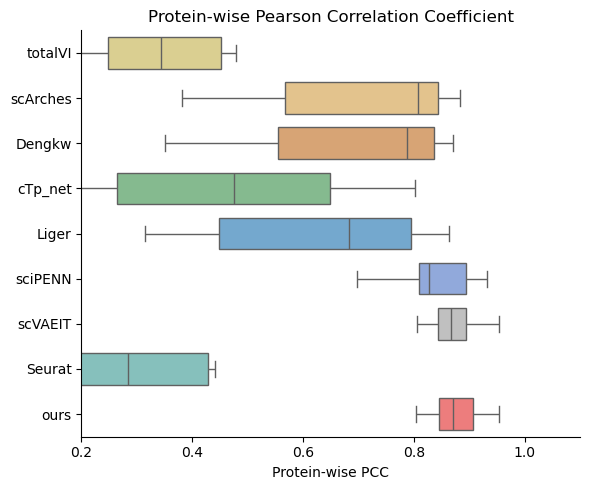

In [16]:
# PCC Protein Boxplot
plt.figure(figsize=(6, 5), dpi=100)
ax = sns.boxplot(data=PCCs_protein, orient="h", linewidth=1, width=0.7, 
                 palette=my_pal, fliersize=0)
ax.set_xlabel("Protein-wise PCC")
ax.set_xlim(0.2, 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title("Protein-wise Pearson Correlation Coefficient")
plt.tight_layout()
plt.savefig(os.path.join(save_path, "pcc_protein_boxplot.png"), dpi=150, bbox_inches="tight")
plt.show()


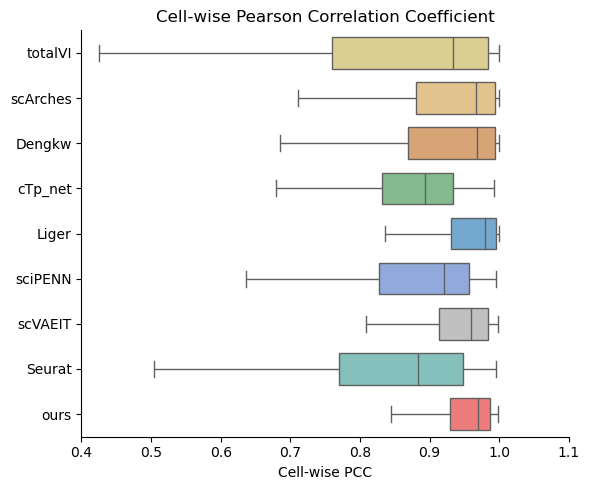

In [17]:
# PCC Cell Boxplot
plt.figure(figsize=(6, 5), dpi=100)
ax = sns.boxplot(data=PCCs_cell, orient="h", linewidth=1, width=0.7,
                 palette=my_pal, fliersize=0)
ax.set_xlabel("Cell-wise PCC")
ax.set_xlim(0.4, 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title("Cell-wise Pearson Correlation Coefficient")
plt.tight_layout()
plt.savefig(os.path.join(save_path, "pcc_cell_boxplot.png"), dpi=150, bbox_inches="tight")
plt.show()


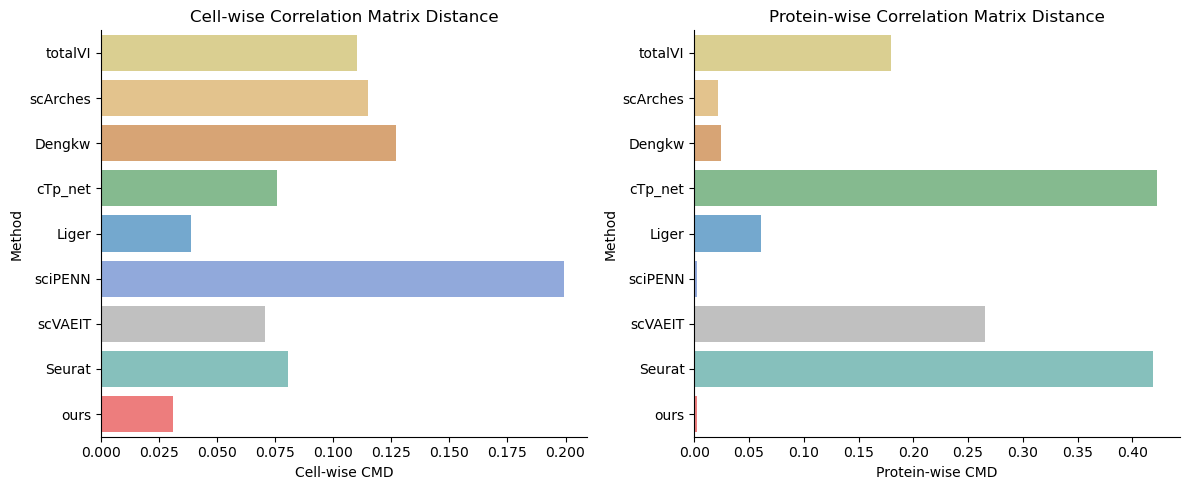

In [18]:
# CMD Barplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# CMD Cell
cmd_cell_df = pd.DataFrame({'Method': method_names, 'CMD': [cmd_cell_results[m] for m in method_names]})
ax1 = sns.barplot(x='CMD', y='Method', data=cmd_cell_df, orient="h", 
                  palette=my_pal, ax=axes[0])
ax1.set_xlabel("Cell-wise CMD")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title("Cell-wise Correlation Matrix Distance")

# CMD Protein
cmd_protein_df = pd.DataFrame({'Method': method_names, 'CMD': [cmd_protein_results[m] for m in method_names]})
ax2 = sns.barplot(x='CMD', y='Method', data=cmd_protein_df, orient="h",
                  palette=my_pal, ax=axes[1])
ax2.set_xlabel("Protein-wise CMD")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title("Protein-wise Correlation Matrix Distance")

plt.tight_layout()
plt.savefig(os.path.join(save_path, "cmd_barplot.png"), dpi=150, bbox_inches="tight")
plt.show()


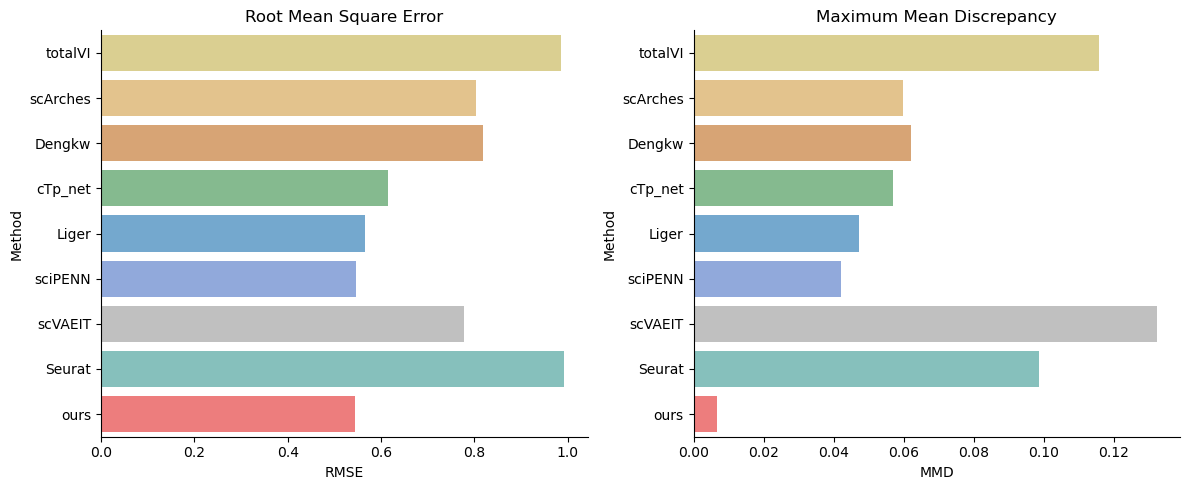

In [19]:
# RMSE and MMD Barplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# RMSE
rmse_df = pd.DataFrame({'Method': method_names, 'RMSE': [rmse_results[m] for m in method_names]})
ax1 = sns.barplot(x='RMSE', y='Method', data=rmse_df, orient="h",
                  palette=my_pal, ax=axes[0])
ax1.set_xlabel("RMSE")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title("Root Mean Square Error")

# MMD
mmd_df = pd.DataFrame({'Method': method_names, 'MMD': [mmd_results[m] for m in method_names]})
ax2 = sns.barplot(x='MMD', y='Method', data=mmd_df, orient="h",
                  palette=my_pal, ax=axes[1])
ax2.set_xlabel("MMD")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title("Maximum Mean Discrepancy")

plt.tight_layout()
plt.savefig(os.path.join(save_path, "rmse_mmd_barplot.png"), dpi=150, bbox_inches="tight")
plt.show()


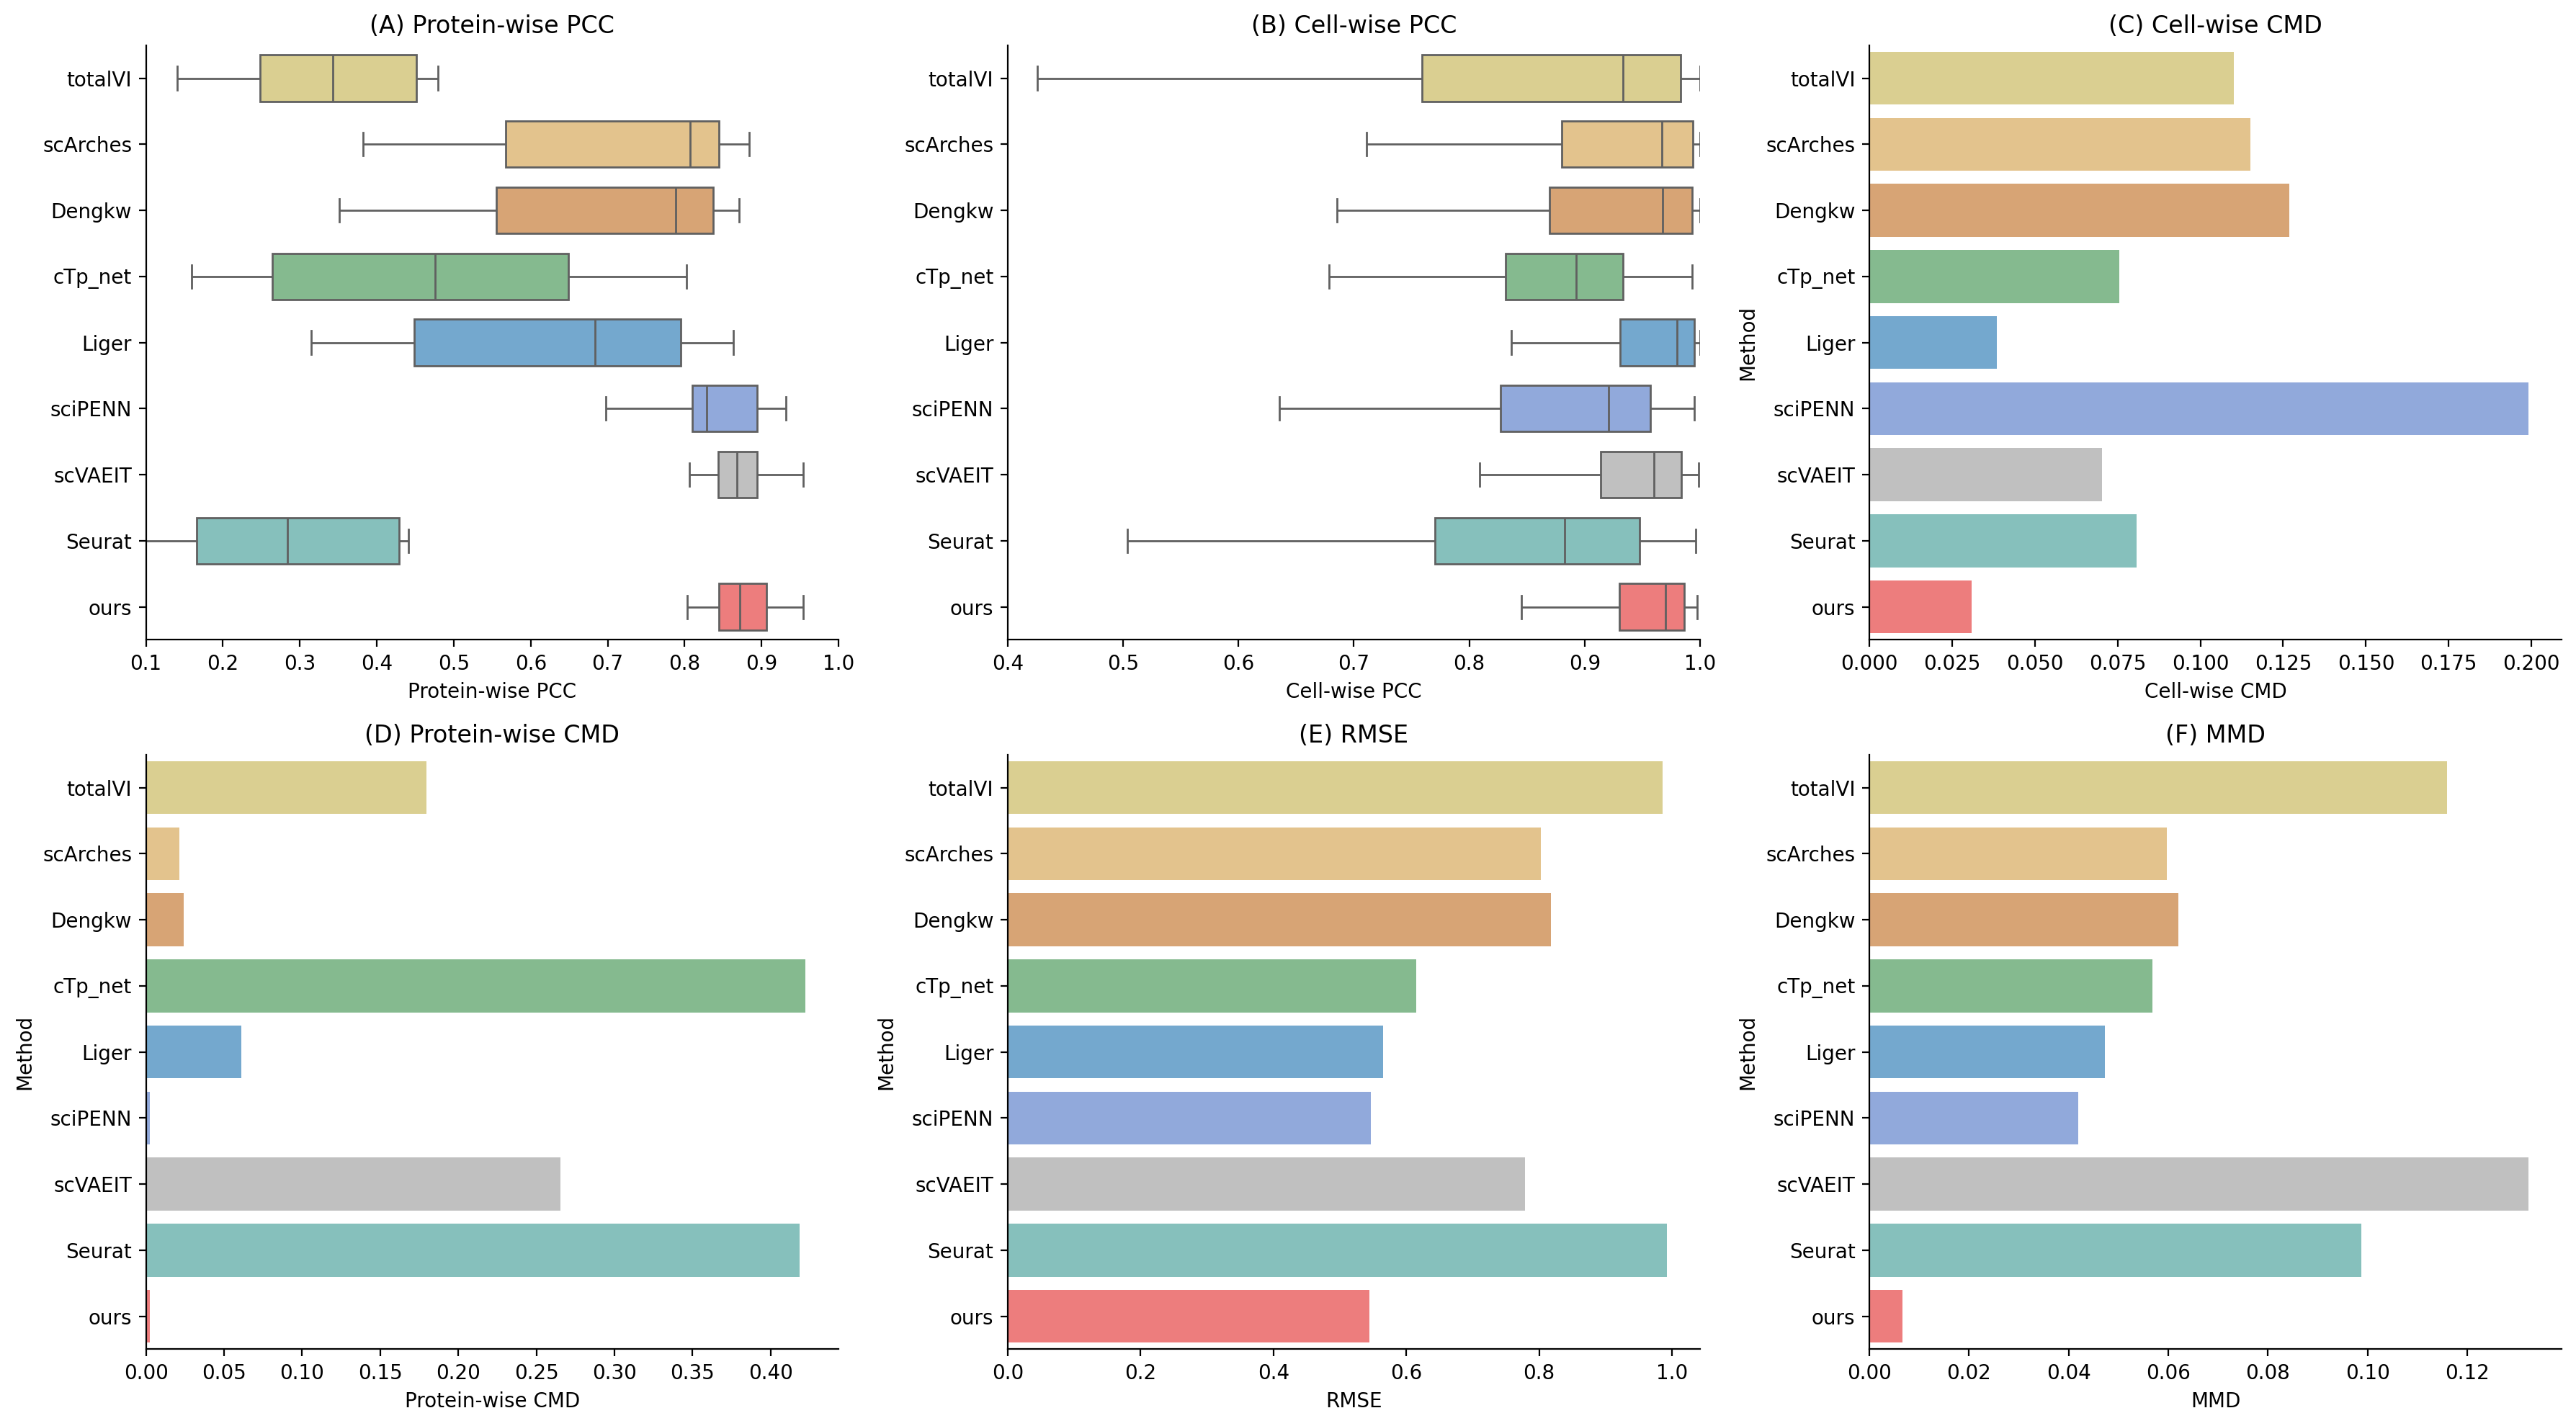

In [ ]:
# Comprehensive metrics plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=200)

# 1. PCC Protein
ax = axes[0, 0]
sns.boxplot(data=PCCs_protein, orient="h", linewidth=1, width=0.7,
            palette=my_pal, fliersize=0, ax=ax)
ax.set_xlabel("Protein-wise PCC")
ax.set_xlim(0.1, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("(A) Protein-wise PCC")

# 2. PCC Cell
ax = axes[0, 1]
sns.boxplot(data=PCCs_cell, orient="h", linewidth=1, width=0.7,
            palette=my_pal, fliersize=0, ax=ax)
ax.set_xlabel("Cell-wise PCC")
ax.set_xlim(0.4, 1.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("(B) Cell-wise PCC")

# 3. CMD Cell
ax = axes[0, 2]
sns.barplot(x='CMD', y='Method', data=cmd_cell_df, orient="h",
            palette=my_pal, ax=ax)
ax.set_xlabel("Cell-wise CMD")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("(C) Cell-wise CMD")

# 4. CMD Protein
ax = axes[1, 0]
sns.barplot(x='CMD', y='Method', data=cmd_protein_df, orient="h",
            palette=my_pal, ax=ax)
ax.set_xlabel("Protein-wise CMD")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("(D) Protein-wise CMD")

# 5. RMSE
ax = axes[1, 1]
sns.barplot(x='RMSE', y='Method', data=rmse_df, orient="h",
            palette=my_pal, ax=ax)
ax.set_xlabel("RMSE")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("(E) RMSE")

# 6. MMD
ax = axes[1, 2]
sns.barplot(x='MMD', y='Method', data=mmd_df, orient="h",
            palette=my_pal, ax=ax)
ax.set_xlabel("MMD")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("(F) MMD")

plt.tight_layout()
plt.savefig(os.path.join(save_path, "all_metrics_summary.png"), dpi=150, bbox_inches="tight")
plt.show()